In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'Sukuna.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(194, 259, 3)

In [3]:
def rotate(im, angle):
    a = np.deg2rad(angle)
    R = np.array([[np.cos(a), np.sin(a)], [-np.sin(a), np.cos(a)]])

    h, w = im.shape[:2]
    new_w = int(np.ceil(h * abs(np.sin(a)) + w * abs(np.cos(a))))
    new_h = int(np.ceil(h * abs(np.cos(a)) + w * abs(np.sin(a))))

    t = np.array([new_w / 2, new_h / 2]) - R @ np.array([w / 2, h / 2])
    M = np.hstack([R, t.reshape(2, 1)])
    return cv2.warpAffine(im, M, (new_w, new_h)), (new_w, new_h)

In [4]:
tilted, tilted_size = rotate(img, 45)
fixed, fixed_size = rotate(tilted, -45)

print('original:', img.shape[1], img.shape[0])
print('tilted:', tilted_size)
print('fixed:', fixed_size)

original: 259 194
tilted: (321, 321)
fixed: (454, 454)


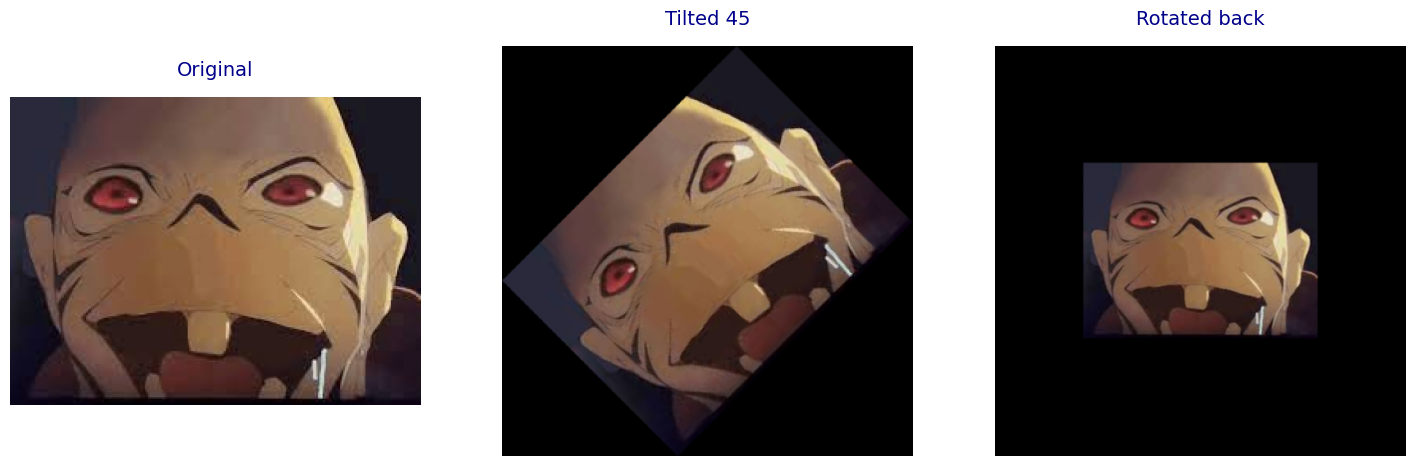

In [5]:
panels = [('Original', img), ('Tilted 45', tilted), ('Rotated back', fixed)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [6]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task2_rotated.png', cv2.cvtColor(fixed, cv2.COLOR_RGB2BGR))

True

Rotation matrix is [[cos, sin], [-sin, cos]]. Image y goes down so this one turns it counter clockwise for a positive angle.

New size: new_w = h|sin| + w|cos| and new_h = h|cos| + w|sin|. These are the bounding box of the rotated rectangle. Without them the corners get chopped since the canvas stays the old size. The translation is the new center minus R @ old center so the rotation happens about the middle.

The fixed image is bigger than the original because the tilted one already has black corners from the first rotation, and those get rotated back too. The picture itself is upright again.